In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('sales_data.csv')

In [6]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [9]:
# Basic info
print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        5000 non-null   int64         
 1   OrderDate      5000 non-null   datetime64[ns]
 2   CustomerID     5000 non-null   object        
 3   Age            5000 non-null   int64         
 4   Gender         5000 non-null   object        
 5   Region         5000 non-null   object        
 6   Category       5000 non-null   object        
 7   Product        5000 non-null   object        
 8   Quantity       5000 non-null   int64         
 9   UnitPrice      5000 non-null   float64       
 10  DiscountPct    5000 non-null   int64         
 11  TotalAmount    5000 non-null   float64       
 12  SalesChannel   5000 non-null   object        
 13  PaymentMethod  5000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memory usage: 547.

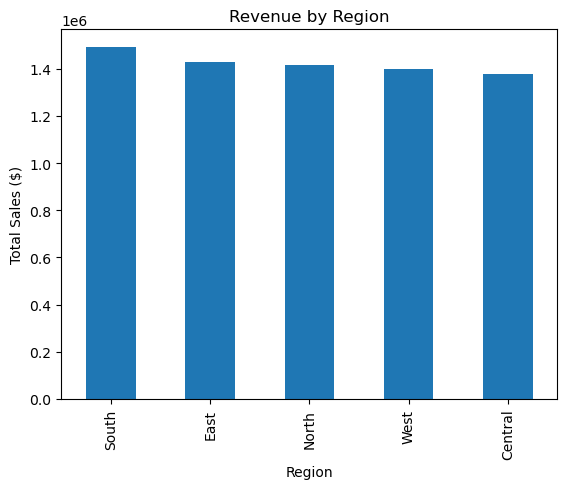

In [10]:
# 1. Revenue by region
region_sales = df.groupby('Region')['TotalAmount'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', title='Revenue by Region')
plt.ylabel('Total Sales ($)')
plt.show()

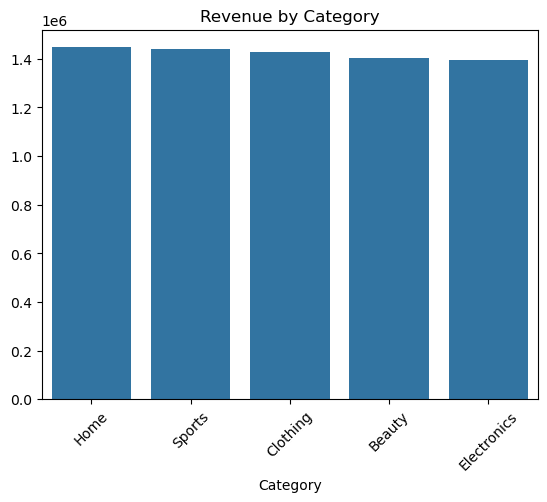

In [11]:
# 2. Revenue by category
cat_sales = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values)
plt.title('Revenue by Category')
plt.xticks(rotation=45)
plt.show()

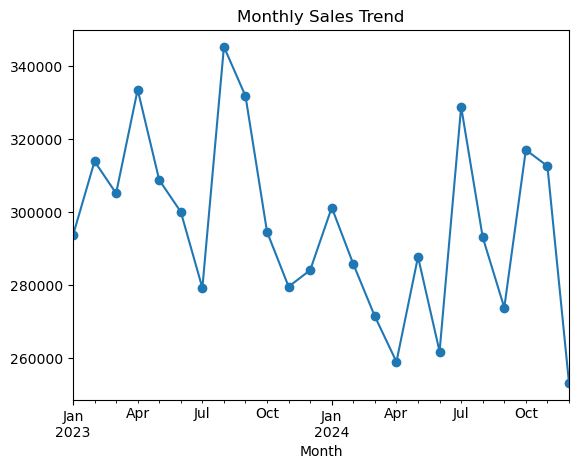

In [12]:
# 3. Monthly sales trend
df['Month'] = df['OrderDate'].dt.to_period('M')
monthly = df.groupby('Month')['TotalAmount'].sum()
monthly.plot(kind='line', marker='o', title='Monthly Sales Trend')
plt.show()

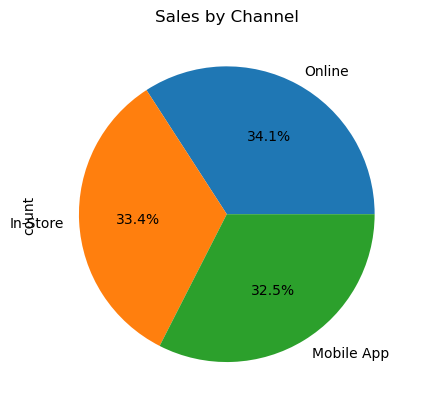

In [13]:
# 4. Sales channel distribution
df['SalesChannel'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Sales by Channel')
plt.show()

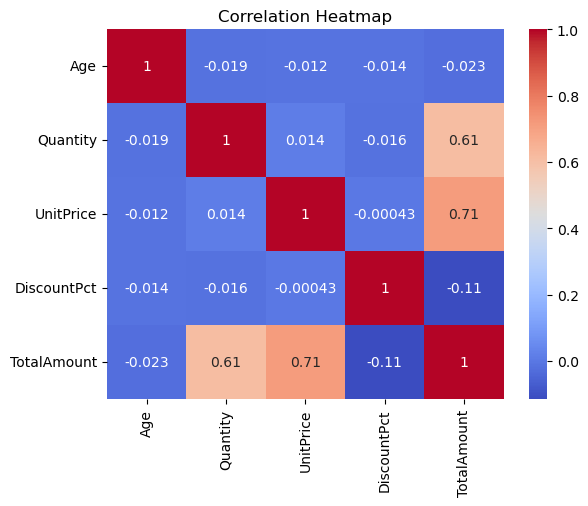

In [14]:
# 5. Correlation heatmap
sns.heatmap(df[['Age','Quantity','UnitPrice','DiscountPct','TotalAmount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# 6. Top 10 customers
top_customers = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
CUST5133    15337.99
CUST4995    10202.28
CUST1159    10091.99
CUST1815     9778.56
CUST7611     9080.59
CUST5005     8906.32
CUST6947     8733.09
CUST4355     8406.20
CUST8461     8188.50
CUST6673     8159.70
Name: TotalAmount, dtype: float64


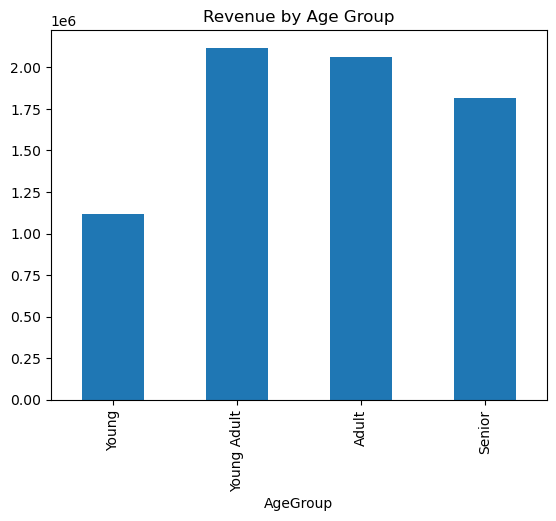

In [20]:
# 7. Age group analysis
bins = [17,25,40,55,70]
labels = ['Young','Young Adult','Adult','Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df.groupby('AgeGroup', observed=False)['TotalAmount'].sum().plot(kind='bar', title='Revenue by Age Group')
plt.show()

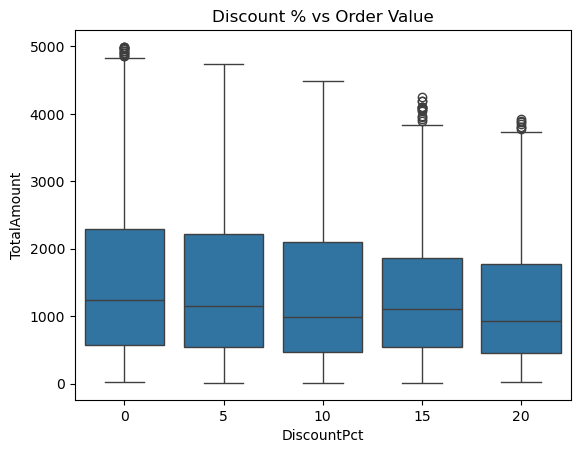

In [18]:
# 8. Discount effect on order value
sns.boxplot(x='DiscountPct', y='TotalAmount', data=df)
plt.title('Discount % vs Order Value')
plt.show()

In [19]:
# Export summary table for dashboard
summary = df.groupby(['Region','Category'])['TotalAmount'].sum().reset_index()
summary.to_csv('region_category_summary.csv', index=False)